In [102]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression


In [103]:
df = pd.read_csv("House-Price-India.csv")

In [104]:
df.head()

,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
0,6762810635,42491,4,2.50,2920,4000,1.5,0,0,5,...,1909,0,122004,52.8878,-114.470,2470,4000,2,51,1400000
1,6762810998,42491,5,2.75,2910,9480,1.5,0,0,3,...,1939,0,122004,52.8852,-114.468,2940,6600,1,53,1200000
2,6762812605,42491,4,2.50,3310,42998,2.0,0,0,3,...,2001,0,122005,52.9532,-114.321,3350,42847,3,76,838000
3,6762812919,42491,3,2.00,2710,4500,1.5,0,0,4,...,1929,0,122006,52.9047,-114.485,2060,4500,1,51,805000
4,6762813105,42491,3,2.50,2600,4750,1.0,0,0,4,...,1951,0,122007,52.9133,-114.590,2380,4750,1,67,790000


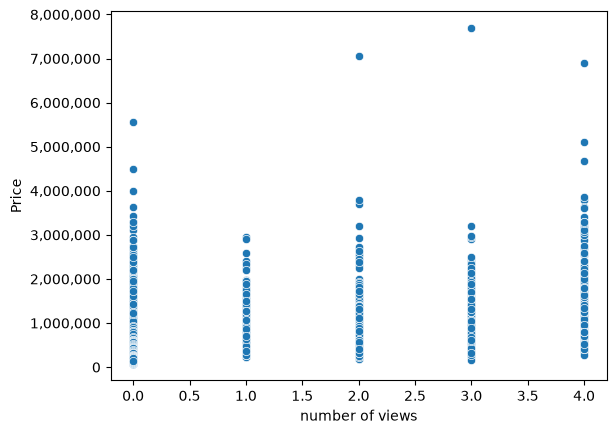

In [105]:
sns.scatterplot(data=df,x='number of views',y='Price')

plt.gca().yaxis.set_major_formatter(
    ticker.StrMethodFormatter('{x:,.0f}')
)

plt.show()

In [106]:
df.corr(numeric_only=True)['Price'].sort_values(ascending=False)

Price                                    1.000000
living area                              0.712276
grade of the house                       0.671805
Area of the house(excluding basement)    0.615179
living_area_renov                        0.585021
number of bathrooms                      0.532031
number of views                          0.394954
Area of the basement                     0.330499
number of bedrooms                       0.308165
Lattitude                                0.297570
waterfront present                       0.263943
number of floors                         0.262649
Renovation Year                          0.133362
lot area                                 0.082117
lot_area_renov                           0.075697
Built Year                               0.050936
condition of the house                   0.040609
Longitude                                0.024807
Number of schools nearby                 0.009904
Distance from the airport                0.004074


In [107]:
features = ['living area',
            'grade of the house',
            'number of bathrooms',
            'number of bedrooms',
            'number of floors',
            ]



In [108]:
df=df[features+['Price']]


In [109]:
df.head()


,living area,grade of the house,number of bathrooms,number of bedrooms,number of floors,Price
0,2920,8,2.50,4,1.5,1400000
1,2910,8,2.75,5,1.5,1200000
2,3310,9,2.50,4,2.0,838000
3,2710,8,2.00,3,1.5,805000
4,2600,9,2.50,3,1.0,790000


In [110]:
df.shape

(14619, 6)

In [111]:
df['Price'].isnull().sum()

np.int64(0)

In [112]:
df['Price'].describe()

count    1.461900e+04
mean     5.388063e+05
std      3.672294e+05
min      7.800000e+04
25%      3.200000e+05
50%      4.500000e+05
75%      6.450000e+05
max      7.700000e+06
Name: Price, dtype: float64

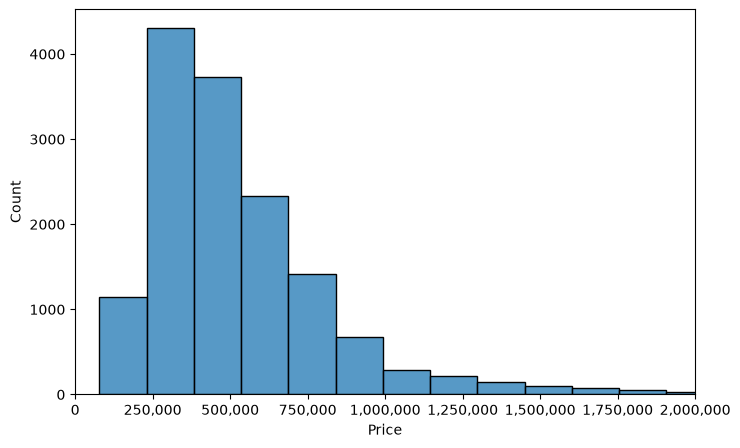

In [113]:
import matplotlib.ticker as ticker
plt.figure(figsize=(8,5))
plt.xlim(0,2000000)
ax = sns.histplot(data=df, x='Price', bins=50)

ax.xaxis.set_major_formatter(
    ticker.StrMethodFormatter('{x:,.0f}')
)


plt.xlabel('Price')
plt.show()

In [114]:
df.dtypes

living area              int64
grade of the house       int64
number of bathrooms    float64
number of bedrooms       int64
number of floors       float64
Price                    int64
dtype: object

In [115]:
(df[features]<0).sum()

living area            0
grade of the house     0
number of bathrooms    0
number of bedrooms     0
number of floors       0
dtype: int64

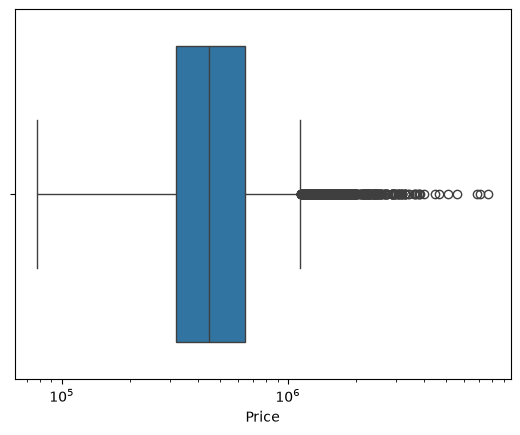

In [116]:
sns.boxplot(x=df['Price'])
plt.xscale('log')
plt.show()

In [117]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)

IQR = Q3 - Q1

upper = Q3+1.5*IQR
print("upper bound:", upper)
print("higher than outliers",(df['Price']>upper).sum())

upper bound: 1132500.0
higher than outliers 760


In [118]:
outliers = df[df['Price']>upper]
outliers.sort_values(by='Price',ascending=False).head(10)

,living area,grade of the house,number of bathrooms,number of bedrooms,number of floors,Price
10502,12050,13,8.00,6,2.5,7700000
2423,10040,11,4.50,5,2.0,7060000
9170,9890,13,7.75,6,2.0,6890000
6243,9200,13,5.75,5,2.0,5570000
10914,8010,12,5.25,5,2.0,5110000
2793,9640,12,6.75,5,1.0,4670000
2906,6430,12,3.00,4,2.0,4490000
10565,7080,12,5.50,4,2.0,4000000
12441,5770,11,4.25,4,2.0,3850000
3945,7050,13,5.50,5,1.0,3800000


In [119]:
x= df.drop(columns='Price')
y = df['Price']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [120]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),features)
    ]
)

In [121]:
pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('model',LinearRegression()),
])


In [122]:
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the

In [123]:
x_train_scaled = preprocessor.fit_transform(x_train)

print("Means:")
print(x_train_scaled.mean().round(2))

print("\nStandard deviations:")
print(x_train_scaled.std().round(2))

Means:
0.0

Standard deviations:
1.0


In [124]:
pipeline.fit(x_train,y_train)

y_pred = pipeline.predict(x_test)

In [125]:
comparison = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted': y_pred
})


comparison.head(10).style.format({
    'Actual Price': '{:,.0f}',
    'Predicted': '{:,.0f}'
})


,Actual Price,Predicted
7983,"546,800","580,244"
6466,"550,000","484,235"
10306,"399,950","436,796"
1217,"940,000","534,515"
12463,"545,000","785,967"
6649,"318,000","179,519"
2585,"315,000","208,646"
2325,"1,800,000","1,373,283"
13863,"1,250,000","916,022"
6890,"825,000","967,677"


In [126]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

print(f"mae : {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

mae : 159,152.46
RMSE: 249,944.29
R² Score: 0.5779


In [127]:
import joblib

In [128]:
joblib.dump(pipeline,"house-price-prediction.joblib")

['house-price-prediction.joblib']

In [129]:
print(x.columns.tolist())

['living area', 'grade of the house', 'number of bathrooms', 'number of bedrooms', 'number of floors']


NameError: name 'X_train' is not defined